# VinDr-CXR annotation exploration
Reproducible pandas EDA of the local VinBigData/VinDr-CXR annotation file. **No model has been trained.**

An annotation row is not a unique image or lesion: multiple readers annotate each X-ray. Outputs contain aggregate summaries only, without image IDs, raw rows, or medical images. Run all cells with Python 3.12 from the repository root or `notebooks/`.

In [1]:
from pathlib import Path
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

assert sys.version_info[:2] == (3, 12), 'Use Python 3.12'
root = Path.cwd()
if root.name == 'notebooks':
    root = root.parent
data_path = root / 'data/raw/train.csv'
if not data_path.is_file():
    raise FileNotFoundError('Place the annotation FILE at data/raw/train.csv')
df = pd.read_csv(data_path)
coords = ['x_min', 'y_min', 'x_max', 'y_max']
assert {'image_id', 'class_name', 'class_id', 'rad_id', *coords} <= set(df.columns)
assert not df[['image_id', 'class_name', 'class_id', 'rad_id']].isna().any().any()
plt.rcParams.update({'figure.figsize': (10, 5), 'figure.dpi': 110,
                     'axes.spines.top': False, 'axes.spines.right': False})
print(f'Python {sys.version.split()[0]} | pandas {pd.__version__}')
print(f'Shape: {df.shape[0]:,} rows x {df.shape[1]} columns')
print(f'Unique X-rays: {df.image_id.nunique():,}; classes: {df.class_name.nunique()}')

Python 3.12.10 | pandas 3.0.5
Shape: 67,914 rows x 8 columns
Unique X-rays: 15,000; classes: 15


## Schema and missing values
Missing coordinates are analyzed by label below, rather than dropped indiscriminately.

In [2]:
display(pd.DataFrame({'dtype': df.dtypes.astype(str), 'missing': df.isna().sum(),
                      'missing_pct': df.isna().mean().mul(100).round(2)}))
print(f'Exact duplicate rows: {df.duplicated().sum():,}')
assert df.groupby('class_id').class_name.nunique().eq(1).all()
assert df.groupby('class_name').class_id.nunique().eq(1).all()

,dtype,missing,missing_pct
image_id,str,0,0.00
class_name,str,0,0.00
class_id,int64,0,0.00
rad_id,str,0,0.00
x_min,float64,31818,46.85
y_min,float64,31818,46.85
x_max,float64,31818,46.85
y_max,float64,31818,46.85


Exact duplicate rows: 0


## Class distribution
Row counts describe annotation volume. Unique-image counts describe images with at least one annotation for a label. Classes overlap, so image percentages need not sum to 100%.

,annotation_rows,unique_images,image_pct
class_name,,,
No finding,31818,10606,70.71
Aortic enlargement,7162,3067,20.45
Cardiomegaly,5427,2300,15.33
Pleural thickening,4842,1981,13.21
Pulmonary fibrosis,4655,1617,10.78
Nodule/Mass,2580,826,5.51
Lung Opacity,2483,1322,8.81
Pleural effusion,2476,1032,6.88
Other lesion,2203,1134,7.56


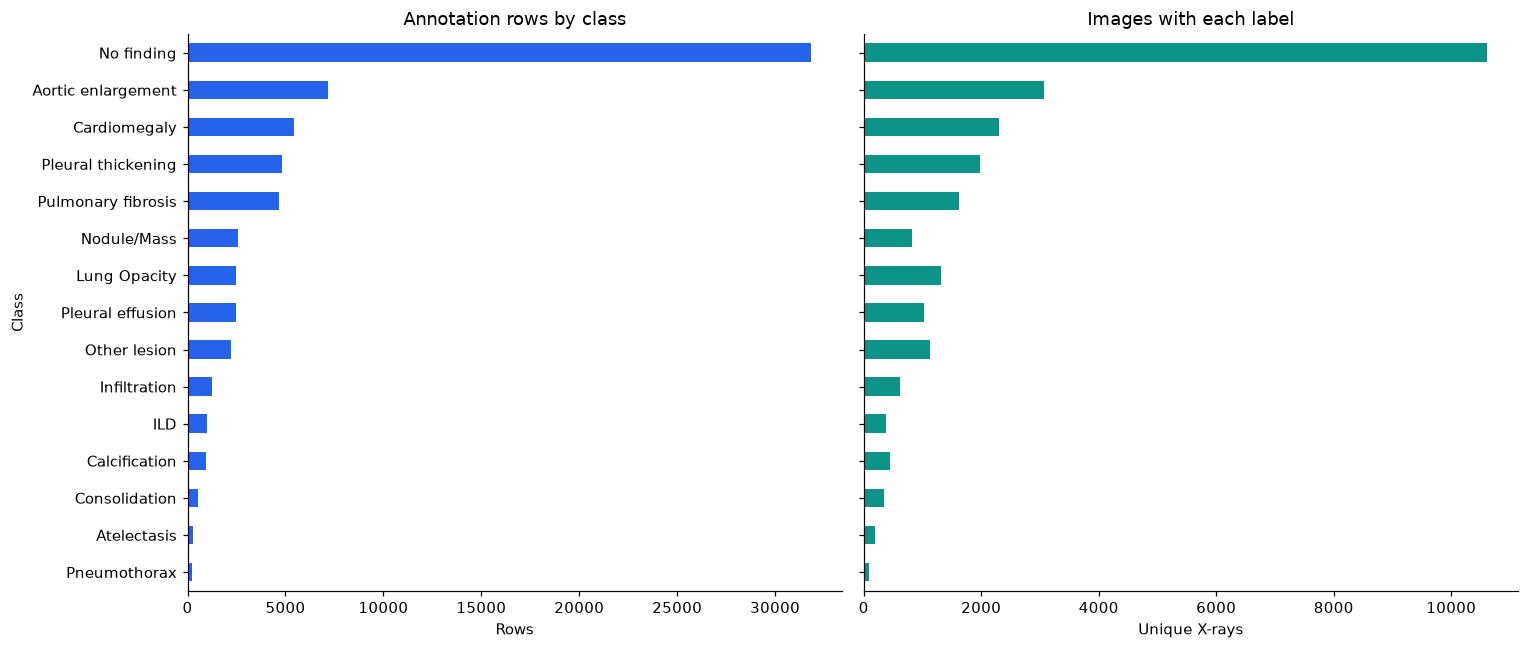

In [3]:
classes = df.groupby('class_name').agg(annotation_rows=('image_id', 'size'),
                                       unique_images=('image_id', 'nunique'))
classes['image_pct'] = (100 * classes.unique_images / df.image_id.nunique()).round(2)
classes = classes.sort_values('annotation_rows', ascending=False)
display(classes)
ordered = classes.sort_values('annotation_rows')
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)
ordered.annotation_rows.plot.barh(ax=axes[0], color='#2563eb')
ordered.unique_images.plot.barh(ax=axes[1], color='#0d9488')
axes[0].set(title='Annotation rows by class', xlabel='Rows', ylabel='Class')
axes[1].set(title='Images with each label', xlabel='Unique X-rays', ylabel='')
fig.tight_layout()
plt.show()

## No Finding analysis
`No finding` is the exact CSV label. These are annotation categories, not verified clinical diagnoses. Check both row and image denominators, including mixed labels.

In [4]:
nf = df.class_name.eq('No finding')
assert nf.any(), 'Expected No finding label missing'
flags = df.assign(nf=nf).groupby('image_id').nf.agg(['any', 'all'])
mixed = int((flags['any'] & ~flags['all']).sum())
display(pd.Series({'No Finding rows': int(nf.sum()),
                   'Images with any No Finding': int(flags['any'].sum()),
                   'Images with only No Finding': int(flags['all'].sum()),
                   'Images with mixed labels': mixed,
                   'Images with abnormal labels': int((~flags['all']).sum())}, name='count').to_frame())
print(f'No Finding share of rows: {nf.mean():.2%}')
print(f'Only No Finding share of images: {flags["all"].mean():.2%}')
display(df.assign(label_group=np.where(nf, 'No finding', 'Abnormal'))
        .groupby('label_group')[coords].agg(lambda s: s.isna().sum()))

,count
No Finding rows,31818
Images with any No Finding,10606
Images with only No Finding,10606
Images with mixed labels,0
Images with abnormal labels,4394


No Finding share of rows: 46.85%
Only No Finding share of images: 70.71%


,x_min,y_min,x_max,y_max
label_group,,,,
Abnormal,0,0,0,0
No finding,31818,31818,31818,31818


## Radiologist distribution
Report annotation rows and unique images per reader. Annotation volume also depends on findings per image and does not measure reader quality.

,annotation_rows,unique_images,no_finding_rows
rad_id,,,
R9,15708,6125,1979
R10,13292,6467,2321
R8,12198,6582,2436
R2,3121,3119,3118
R5,2783,2783,2783
R3,2285,2285,2285
R6,2041,2041,2041
R1,1995,1995,1995
R13,1824,1629,1505


,images
readers_per_image,
3,15000


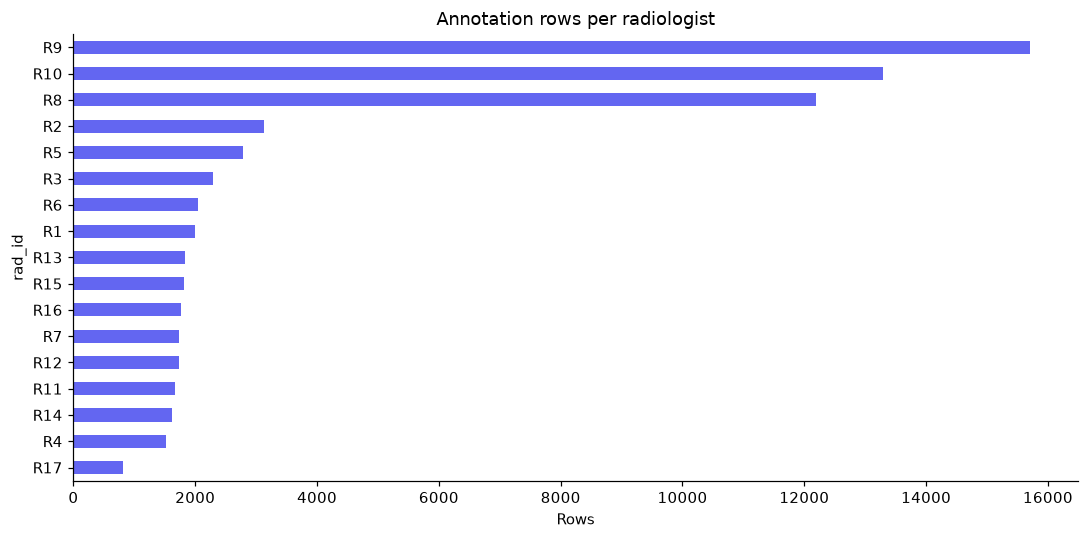

In [5]:
readers = df.groupby('rad_id').agg(annotation_rows=('image_id', 'size'), unique_images=('image_id', 'nunique'))
readers['no_finding_rows'] = df.loc[nf].groupby('rad_id').size().reindex(readers.index, fill_value=0)
display(readers.sort_values('annotation_rows', ascending=False))
readers_per_image = df.groupby('image_id').rad_id.nunique()
display(readers_per_image.value_counts().sort_index().rename_axis('readers_per_image').to_frame('images'))
readers.sort_values('annotation_rows').annotation_rows.plot.barh(color='#6366f1')
plt.title('Annotation rows per radiologist')
plt.xlabel('Rows')
plt.tight_layout()
plt.show()

## Bounding-box count, quality, and geometry
Count abnormal boxes before cross-reader merging. Valid geometry requires finite coordinates, nonnegative origins, and positive width and height. Width/height are in pixels and area in square pixels. Image dimensions are unavailable in this CSV, so boundary checks and normalized areas are out of scope.

,count
Abnormal rows,36096
Complete coordinate rows,36096
No Finding rows with any coordinate,0
Abnormal rows missing coordinates,0
Abnormal rows with invalid geometry,0
Valid abnormal boxes,36096


,width,height,area
count,36096.00,36096.00,36096.00
mean,440.94,391.40,218415.71
std,332.83,328.08,289379.77
min,11.00,3.00,180.00
25%,208.75,189.00,39189.50
50%,323.00,320.00,106471.00
75%,593.00,455.00,311974.50
95%,1141.00,1086.00,733590.00
99%,1315.05,1723.00,1432315.35
max,2938.00,2803.00,4575318.00


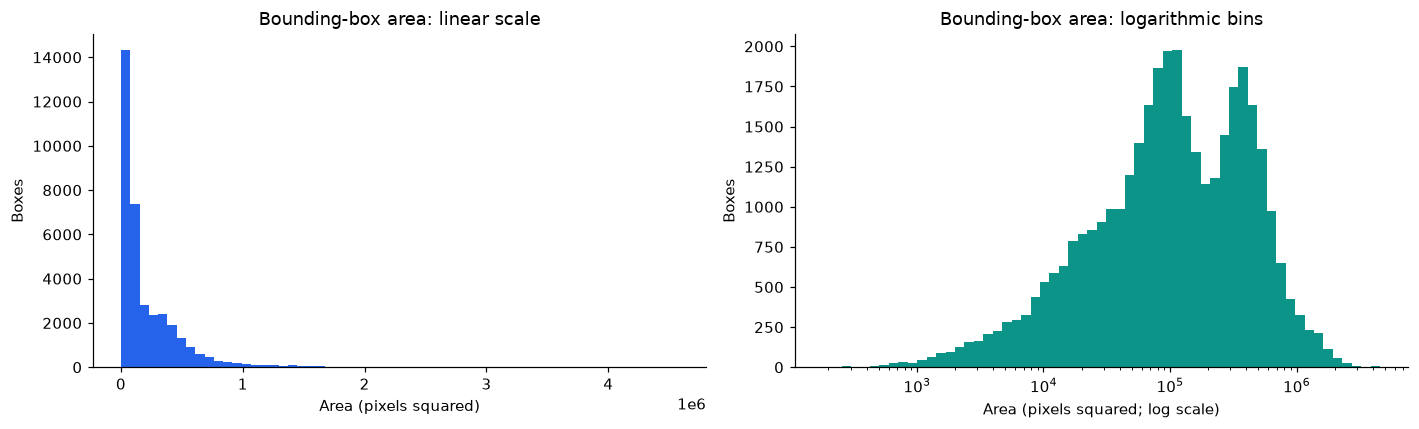

In [6]:
complete = df[coords].notna().all(axis=1)
finite = pd.Series(np.isfinite(df[coords].to_numpy()).all(axis=1), index=df.index)
positive = (df.x_max > df.x_min) & (df.y_max > df.y_min)
nonnegative = (df.x_min >= 0) & (df.y_min >= 0)
valid = ~nf & complete & finite & positive & nonnegative
audit = pd.Series({
    'Abnormal rows': int((~nf).sum()),
    'Complete coordinate rows': int(complete.sum()),
    'No Finding rows with any coordinate': int((nf & df[coords].notna().any(axis=1)).sum()),
    'Abnormal rows missing coordinates': int((~nf & ~complete).sum()),
    'Abnormal rows with invalid geometry': int((~nf & complete & ~(finite & positive & nonnegative)).sum()),
    'Valid abnormal boxes': int(valid.sum())}, name='count')
display(audit.to_frame())
boxes = df.loc[valid, coords].copy()
boxes['width'] = boxes.x_max - boxes.x_min
boxes['height'] = boxes.y_max - boxes.y_min
boxes['area'] = boxes.width * boxes.height
assert len(boxes) > 0
display(boxes[['width', 'height', 'area']].describe(percentiles=[.25, .5, .75, .95, .99]).round(2))
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].hist(boxes.area, bins=60, color='#2563eb')
axes[0].set(title='Bounding-box area: linear scale', xlabel='Area (pixels squared)', ylabel='Boxes')
axes[1].hist(boxes.area, bins=np.geomspace(boxes.area.min(), boxes.area.max(), 60), color='#0d9488')
axes[1].set_xscale('log')
axes[1].set(title='Bounding-box area: logarithmic bins', xlabel='Area (pixels squared; log scale)', ylabel='Boxes')
fig.tight_layout()
plt.show()

## Annotations per image
Total rows include No Finding annotations. Box counts include all reader annotations, with zero for images without valid abnormal boxes. Only aggregate distributions are displayed.

,annotation_rows,valid_boxes
count,15000.00,15000.00
mean,4.53,2.41
std,3.58,4.60
min,3.00,0.00
25%,3.00,0.00
50%,3.00,0.00
75%,4.00,4.00
max,57.00,57.00


,images
annotation_rows_per_image,
3,10976
4,431
5,550
6,725
7,430
8,383
9,303
10,227
11,176


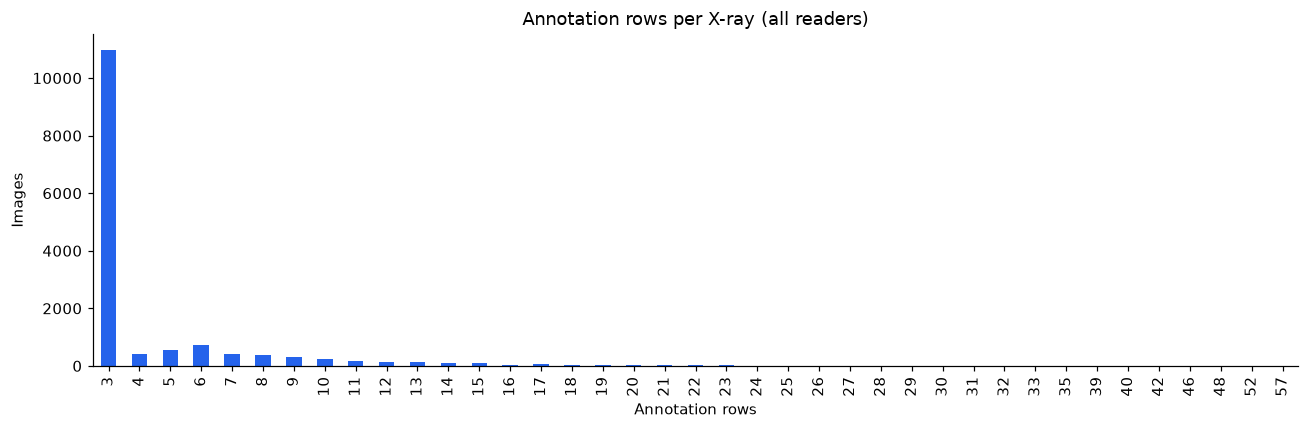

In [7]:
per_image = df.groupby('image_id').size()
boxes_per_image = df.loc[valid].groupby('image_id').size().reindex(per_image.index, fill_value=0)
display(pd.DataFrame({'annotation_rows': per_image.describe(), 'valid_boxes': boxes_per_image.describe()}).round(2))
display(per_image.value_counts().sort_index().rename_axis('annotation_rows_per_image').to_frame('images'))
per_image.value_counts().sort_index().plot.bar(figsize=(12, 4), color='#2563eb')
plt.title('Annotation rows per X-ray (all readers)')
plt.xlabel('Annotation rows')
plt.ylabel('Images')
plt.tight_layout()
plt.show()
assert int(classes.annotation_rows.sum()) == len(df)
assert int(per_image.sum()) == len(df)
assert int(boxes_per_image.sum()) == len(boxes)

## Observations derived from this execution

In [8]:
abnormal = classes.drop(index='No finding').annotation_rows
display(Markdown(f"""
- **{len(df):,} rows across {df.image_id.nunique():,} X-rays**; {df.class_name.nunique()} labels including No Finding.
- **{flags['all'].sum():,} images ({flags['all'].mean():.2%})** have only No Finding annotations; **{mixed}** images mix No Finding and abnormal labels.
- **{len(boxes):,} valid abnormal boxes**; {audit['Abnormal rows missing coordinates']} abnormal rows with missing coordinates and {audit['Abnormal rows with invalid geometry']} with invalid geometry.
- **{abnormal.idxmax()} ({abnormal.max():,} rows)** versus **{abnormal.idxmin()} ({abnormal.min():,})** gives a **{abnormal.max()/abnormal.min():.1f}:1** annotation imbalance, not disease prevalence.
- **{len(readers)} radiologists**; each image has **{readers_per_image.min()}–{readers_per_image.max()}** distinct readers. Cross-reader annotations require an aggregation policy before training.
- Annotation rows per image: mean **{per_image.mean():.2f}**, median **{per_image.median():.0f}**, maximum **{per_image.max()}**.
- Median box width/height: **{boxes.width.median():,.0f}/{boxes.height.median():,.0f} pixels**; median area **{boxes.area.median():,.0f} pixels²**, mean area **{boxes.area.mean():,.0f} pixels²**. The upper tail motivates scale-aware analysis once image dimensions are available.
- **{df.duplicated().sum()} exact duplicate rows**; this does not test spatial overlap or reader agreement.
"""))


- **67,914 rows across 15,000 X-rays**; 15 labels including No Finding.
- **10,606 images (70.71%)** have only No Finding annotations; **0** images mix No Finding and abnormal labels.
- **36,096 valid abnormal boxes**; 0 abnormal rows with missing coordinates and 0 with invalid geometry.
- **Aortic enlargement (7,162 rows)** versus **Pneumothorax (226)** gives a **31.7:1** annotation imbalance, not disease prevalence.
- **17 radiologists**; each image has **3–3** distinct readers. Cross-reader annotations require an aggregation policy before training.
- Annotation rows per image: mean **4.53**, median **3**, maximum **57**.
- Median box width/height: **323/320 pixels**; median area **106,471 pixels²**, mean area **218,416 pixels²**. The upper tail motivates scale-aware analysis once image dimensions are available.
- **0 exact duplicate rows**; this does not test spatial overlap or reader agreement.


## Limitations and next steps
Annotation-only EDA does not establish clinical performance. No image inspection, patient linkage, splitting, box fusion, or training has been completed. No Finding is not proof of absence of disease; pixel areas are not physical lesion sizes.

Next: inspect DICOM dimensions and validate box bounds; define reader aggregation; create leakage-aware splits using patient information if available (otherwise document the image-level limitation); train a baseline and evaluate per-class detection metrics and errors. Keep source data and image identifiers outside version control.